# Taxi vs Rideshare: Time Series, Airport, and Event-Day Analysis

Uses the pre-aggregated CSVs from `scripts/aggregate_timeseries_and_summaries.py`
(all of 2025, all months, one pass over the raw yellow + green + HVFHV data). "Taxi"
covers **yellow + green** -- green ("boro") taxis are licensed specifically for upper
Manhattan and the outer boroughs that yellow taxis are largely excluded from, so
they're a real taxi-side competitor to rideshare there, even though their citywide
volume is tiny (~590K/yr vs 48.6M yellow / 243.6M rideshare):

1. **Full-year time series** of daily trip volume by mode (Yellow / Green / Uber / Lyft).
2. **"Typical week" profile** — 15-minute-resolution intraday volume by mode, plus taxi
   market share (yellow+green vs all trips) on a secondary axis.
3. **Airport dropoff summary** (JFK / LaGuardia) by mode, joined with Central Park
   weather to see whether/how weather relates to airport travel by mode.
4. **Special-event comparison** — average trip distance/duration/cost by mode, on
   days+boroughs with a permitted NYC special event vs without (`data/export.csv`).
5. **Weather deep dive** — continuous temperature/precipitation correlations and
   hourly rain-timing analysis, normalized so modes are comparable despite very
   different baseline volumes.

### Comparability caveats (read before interpreting cost/tip figures)
- Yellow/green `tip_amount` only captures **credit card** tips (TLC data dictionary
  rule) — cash tips are not recorded at all. HVFHV `tips` captures **all** in-app
  tips. So taxi tip and total-cost figures are a systematic underestimate relative
  to rideshare's, not a real behavioural difference.
- Yellow/green `total_amount` is a metered fare + fixed surcharges. HVFHV pricing is
  dynamic (surge-based); the `cost` field here is a same-shape reconstruction
  (base fare + tolls + fees + tax + tips) but isn't fare-mechanism-equivalent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

DATA_DIR = "../data"
PLOTS_DIR = "../plots"

# fixed categorical colors (same 3 slots used for the choropleth notebook's
# palette), assigned once and reused across every chart in this notebook.
# Green taxi is a late addition with tiny volume (~590K/yr vs 48.6M yellow /
# 243.6M rideshare) -- given it as an actual green hue rather than the next
# sequential palette slot, since as a thin, usually-invisible line/band its
# legend needs to be intuitively identifiable rather than palette-order-safe.
MODE_COLORS = {
    "yellow": "#2a78d6",
    "green": "#008300",
    "uber": "#eb6834",
    "lyft": "#1baf7a",
}
MODE_ORDER = ["yellow", "green", "uber", "lyft"]
MODE_LABELS = {"yellow": "Yellow Taxi", "green": "Green Taxi", "uber": "Uber", "lyft": "Lyft"}
TAXI_MODES = ["yellow", "green"]
RIDESHARE_MODES = ["uber", "lyft"]

# seaborn theme: restyles every matplotlib figure below it (fonts, spines,
# grid) without needing to rewrite each chart individually. Colors stay our
# own MODE_COLORS/validated palette, not seaborn's default palette -- this is
# a styling layer, not a recoloring.
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110       # on-screen (keeps the notebook responsive)
plt.rcParams["savefig.dpi"] = 250      # exported PNGs (report/print quality)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514e"
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.6
plt.rcParams["font.family"] = "sans-serif"

## 0. The long view: taxis vs rideshare, 2009–2025

Everything below is a deep dive on 2025, so first the seventeen-year context: how did
NYC get from a yellow-cab monopoly to the rideshare-dominated market the rest of this
notebook analyses?

Counting the raw trip records back to 2009 would mean scanning billions of rows, so this
uses the TLC's own aggregated **Monthly Data Report** (trips per day by license class,
one ~80 KB CSV) instead, fetched by `scripts/download_monthly_trip_counts.py`. That
report only starts in 2010, so 2009 is filled in with exact row counts read from the
parquet footers of the twelve 2009 yellow-taxi files via HTTP range requests (~10 KB
per month, no full downloads). "FHV - High Volume" is the TLC's license class for
app-dispatch fleets (Uber, Lyft, Via, Juno), tracked separately from 2015; Uber
operated as an ordinary black-car base from its May 2011 NYC launch, but those early
volumes are folded into the generic black-car class, which is why the rideshare line
only begins in 2015.

Thin lines are monthly values; bold lines with markers are annual averages.

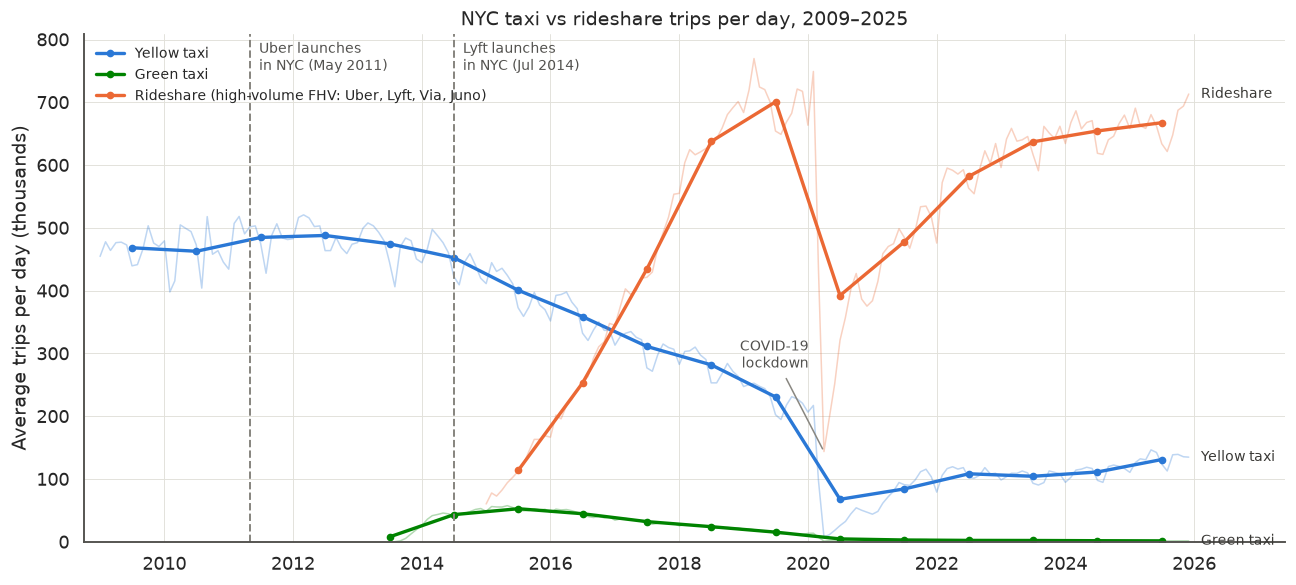

=== Annual average trips per day (thousands) ===
mode        Green  Rideshare  Yellow
month                               
2009-01-01    NaN        NaN   468.3
2010-01-01    NaN        NaN   462.8
2011-01-01    NaN        NaN   484.8
2012-01-01    NaN        NaN   487.9
2013-01-01    7.9        NaN   474.6
2014-01-01   43.4        NaN   452.5
2015-01-01   52.7      113.8   400.6
2016-01-01   44.8      253.1   358.6
2017-01-01   32.2      434.9   311.1
2018-01-01   24.1      637.7   281.8
2019-01-01   15.4      700.9   230.7
2020-01-01    4.7      392.3    67.7
2021-01-01    2.9      478.0    84.3
2022-01-01    2.3      582.0   108.4
2023-01-01    2.2      637.1   104.4
2024-01-01    1.8      654.4   111.3
2025-01-01    1.6      667.5   131.1

Yellow taxi peak: 2012 (487,929/day) | 2019, last pre-COVID year: 230,691/day (-53%) | 2025: 131,133/day
First month rideshare out-trips yellow: December 2016


In [2]:
# produced by scripts/download_monthly_trip_counts.py (TLC aggregate Monthly Data
# Report, plus 2009 from parquet footers) -- no raw trip records involved
longrun = pd.read_csv(f"{DATA_DIR}/processed/monthly_trip_counts_2009_2025.csv", parse_dates=["month"])
monthly = longrun.pivot(index="month", columns="mode", values="trips_per_day").sort_index()
yearly = monthly.resample("YS").mean()

LONGRUN_MODES = ["yellow", "green", "rideshare"]
LONGRUN_COLORS = {"yellow": MODE_COLORS["yellow"], "green": MODE_COLORS["green"],
                  "rideshare": MODE_COLORS["uber"]}
LONGRUN_LABELS = {
    "yellow": "Yellow taxi",
    "green": "Green taxi",
    "rideshare": "Rideshare (high-volume FHV: Uber, Lyft, Via, Juno)",
}
LAUNCHES = [
    (pd.Timestamp("2011-05-01"), "Uber launches\nin NYC (May 2011)"),
    (pd.Timestamp("2014-07-01"), "Lyft launches\nin NYC (Jul 2014)"),
]

fig, ax = plt.subplots(figsize=(12, 5.5))
for mode in LONGRUN_MODES:
    c = LONGRUN_COLORS[mode]
    ax.plot(monthly.index, monthly[mode] / 1000, color=c, linewidth=1, alpha=0.3)
    # annual averages drawn at each year's midpoint, over the monthly trace
    ax.plot(yearly.index + pd.Timedelta(days=182), yearly[mode] / 1000, color=c,
            linewidth=2.2, marker="o", markersize=4, label=LONGRUN_LABELS[mode])
    last = monthly[mode].dropna()
    ax.annotate(LONGRUN_LABELS[mode].split(" (")[0], (last.index[-1], last.iloc[-1] / 1000),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color="#3a3936")

ax.set_ylim(bottom=0)
for when, label in LAUNCHES:
    ax.axvline(when, color="#898781", linestyle="--", linewidth=1.3)
    ax.annotate(label, (when, ax.get_ylim()[1]), xytext=(6, -4), textcoords="offset points",
                va="top", fontsize=9, color="#52514e")
lockdown = pd.Timestamp("2020-04-01")
ax.annotate("COVID-19\nlockdown", (lockdown, monthly.loc[lockdown, "rideshare"] / 1000),
            xytext=(-10, 55), textcoords="offset points", ha="right", fontsize=9, color="#52514e",
            arrowprops=dict(arrowstyle="-", color="#898781", linewidth=1))

ax.set_xlim(pd.Timestamp("2008-10-01"), pd.Timestamp("2027-06-01"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Average trips per day (thousands)")
ax.set_title("NYC taxi vs rideshare trips per day, 2009\u20132025")
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/longrun_trips_timeseries_2009_2025.png")
plt.show()

print("=== Annual average trips per day (thousands) ===")
print((yearly / 1000).round(1).rename(columns=str.title).to_string())
peak = yearly["yellow"].idxmax()
print(f"\nYellow taxi peak: {peak.year} ({yearly.loc[peak, 'yellow']:,.0f}/day) | "
      f"2019, last pre-COVID year: {yearly.loc['2019-01-01', 'yellow']:,.0f}/day "
      f"({yearly.loc['2019-01-01', 'yellow'] / yearly.loc[peak, 'yellow'] - 1:+.0%}) | "
      f"2025: {yearly.loc['2025-01-01', 'yellow']:,.0f}/day")
print(f"First month rideshare out-trips yellow: "
      f"{(monthly['rideshare'] > monthly['yellow']).idxmax():%B %Y}")

## 1. Trip volume and taxi market share around major holidays

A full smooth year of daily totals doesn't say much on its own -- the interesting
question is whether *specific* high-demand occasions (bowl games, Thanksgiving,
Christmas, New Year's Eve) shift either the volume or the taxi-vs-rideshare split.
Each panel below zooms into the run-up to one date, plotting total daily trips
(left axis, plain line, no fill) against taxi market share (right axis, fixed 0-1
scale, dashed) -- the same dual-axis convention used again in the "typical week"
chart further down. The dotted vertical line marks the holiday itself.

Note: our data covers only calendar year 2025, so New Year's Eve here is Dec 31
2025 (we can see the run-up but not the Jan 1 2026 aftermath).

2025 totals:
mode
yellow     42141342
green        489778
uber      167672188
lyft       64364060
Name: trips, dtype: int64

Rideshare share of total, Jan vs Dec:
month
1     0.860512
12    0.844623
Name: rideshare_share, dtype: float64


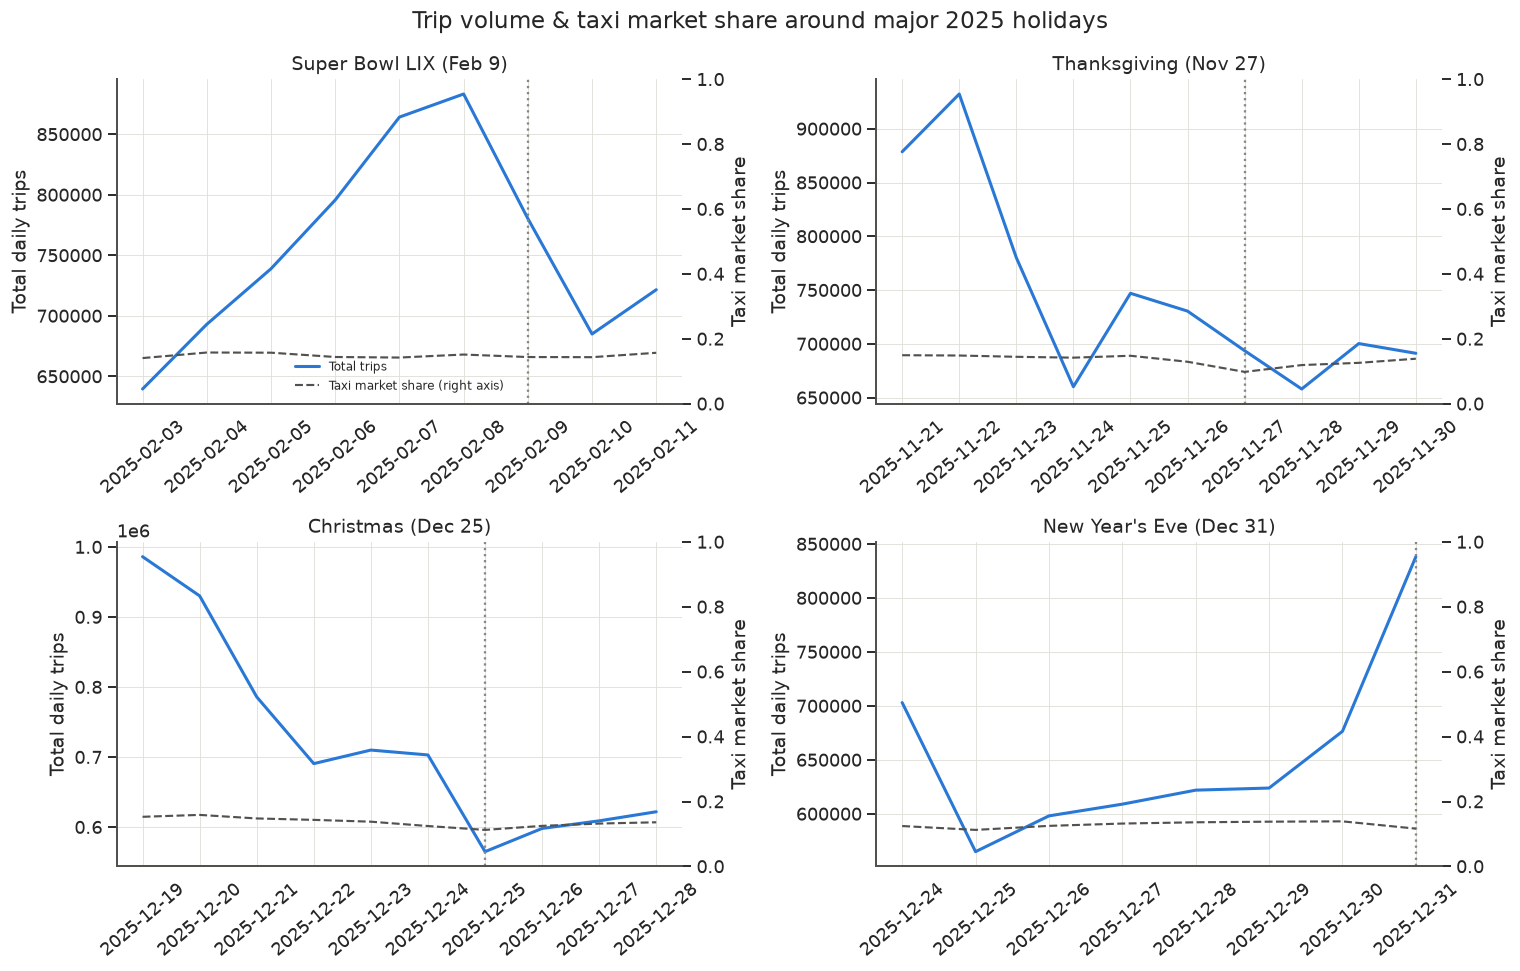

=== Holiday day vs surrounding window average ===
Super Bowl LIX (Feb 9): total trips 780,447 (window avg 755,783, +3.3%) | taxi share 14.4% (window avg 14.9%)
Thanksgiving (Nov 27): total trips 693,714 (window avg 747,258, -7.2%) | taxi share 9.8% (window avg 13.4%)
Christmas (Dec 25): total trips 564,997 (window avg 720,054, -21.5%) | taxi share 11.3% (window avg 13.7%)
New Year's Eve (Dec 31): total trips 838,288 (window avg 654,490, +28.1%) | taxi share 11.6% (window avg 12.8%)


In [3]:
daily = pd.read_csv(f"{DATA_DIR}/processed/daily_counts_by_mode_2025.csv", parse_dates=["pickup_date"])
daily_wide = (
    daily.pivot(index="pickup_date", columns="mode", values="trip_count")
    .reindex(columns=MODE_ORDER)
    .fillna(0)
)
daily_wide["total"] = daily_wide[MODE_ORDER].sum(axis=1)
daily_wide["taxi_total"] = daily_wide[TAXI_MODES].sum(axis=1)
daily_wide["taxi_market_share"] = daily_wide["taxi_total"] / daily_wide["total"]

print("2025 totals:")
print(daily_wide[MODE_ORDER].sum().rename("trips"))
print(f"\nRideshare share of total, Jan vs Dec:")
monthly_share = (
    daily_wide.assign(month=daily_wide.index.month)
    .groupby("month")[["uber", "lyft", "total"]]
    .sum()
    .assign(rideshare_share=lambda d: (d["uber"] + d["lyft"]) / d["total"])
)
print(monthly_share["rideshare_share"].loc[[1, 12]])

# holiday windows: (start, end, the holiday date itself), all within 2025
HOLIDAY_WINDOWS = {
    "Super Bowl LIX (Feb 9)": ("2025-02-03", "2025-02-11", "2025-02-09"),
    "Thanksgiving (Nov 27)": ("2025-11-21", "2025-11-30", "2025-11-27"),
    "Christmas (Dec 25)": ("2025-12-19", "2025-12-28", "2025-12-25"),
    "New Year's Eve (Dec 31)": ("2025-12-24", "2025-12-31", "2025-12-31"),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
legend_handles, legend_labels = None, None
for ax, (title, (start, end, holiday)) in zip(axes.flat, HOLIDAY_WINDOWS.items()):
    window = daily_wide.loc[start:end]
    (line1,) = ax.plot(window.index, window["total"], color="#2a78d6", linewidth=2, label="Total trips")
    ax.axvline(pd.Timestamp(holiday), color="#898781", linestyle=":", linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel("Total daily trips")
    ax.tick_params(axis="x", rotation=40)

    ax2 = ax.twinx()
    (line2,) = ax2.plot(window.index, window["taxi_market_share"], color="#52514e", linestyle="--", linewidth=1.4,
                          label="Taxi market share")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Taxi market share")
    ax2.grid(False)

    if legend_handles is None:
        legend_handles, legend_labels = [line1, line2], ["Total trips", "Taxi market share (right axis)"]

axes[0, 0].legend(legend_handles, legend_labels, loc="lower center", frameon=False, fontsize=8)
fig.suptitle("Trip volume & taxi market share around major 2025 holidays")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/holiday_volume_and_share_2025.png")
plt.show()

# headline: holiday day itself vs the surrounding window's average
print("=== Holiday day vs surrounding window average ===")
for title, (start, end, holiday) in HOLIDAY_WINDOWS.items():
    window = daily_wide.loc[start:end]
    hday = daily_wide.loc[pd.Timestamp(holiday)]
    print(f"{title}: total trips {hday['total']:,.0f} (window avg {window['total'].mean():,.0f}, "
          f"{(hday['total']/window['total'].mean()-1):+.1%}) | taxi share {hday['taxi_market_share']:.1%} "
          f"(window avg {window['taxi_market_share'].mean():.1%})")

## 2. "Typical week" intraday profile (15-minute resolution)

A continuous week (Monday 00:00 -> Sunday 23:45 in 15-minute steps), each point averaged
across all ~52 occurrences of that weekday+time in 2025 (true zero-trip windows count as
zero in the average, not just omitted) — so the diurnal rhythm (overnight lull, morning/
evening peaks) and the weekday-vs-weekend shift are both visible in one continuous line
per mode.

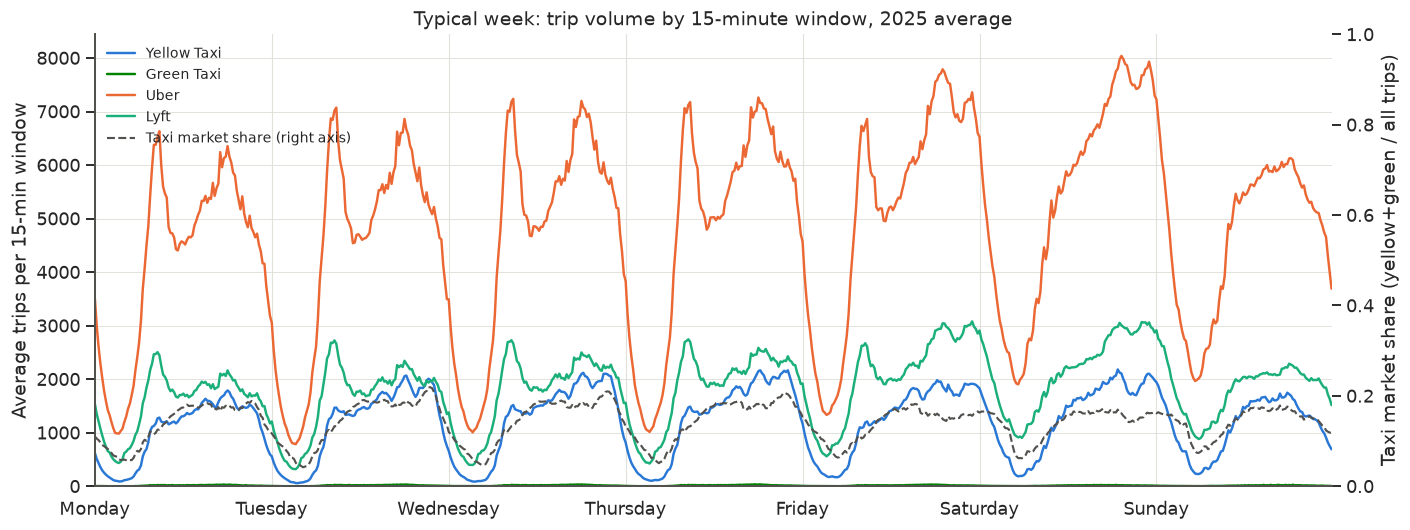

Yellow Taxi: peak Saturday 18:45 (2182 avg trips) | trough Tuesday 03:30 (58 avg trips)
Green Taxi: peak Thursday 17:30 (36 avg trips) | trough Tuesday 03:30 (0 avg trips)
Uber: peak Saturday 19:15 (8039 avg trips) | trough Tuesday 03:15 (787 avg trips)
Lyft: peak Friday 23:00 (3079 avg trips) | trough Tuesday 03:15 (319 avg trips)

Taxi market share: highest Tuesday 21:15 (21.9%) | lowest Tuesday 04:15 (4.2%)


In [4]:
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

intraday = pd.read_csv(f"{DATA_DIR}/processed/intraday_15min_by_date_mode_2025.csv", parse_dates=["pickup_date"])

# full (date x 15-min bucket x mode) grid, so genuinely-zero windows count as 0 in
# the average rather than being silently omitted
all_dates = intraday["pickup_date"].unique()
full_index = pd.MultiIndex.from_product(
    [all_dates, range(96), MODE_ORDER], names=["pickup_date", "bucket_idx", "mode"]
)
intraday_full = (
    intraday.set_index(["pickup_date", "bucket_idx", "mode"])["trip_count"]
    .reindex(full_index, fill_value=0)
    .reset_index()
)
intraday_full["dow"] = intraday_full["pickup_date"].dt.day_name()

profile = intraday_full.groupby(["dow", "bucket_idx", "mode"], observed=True)["trip_count"].mean().reset_index()
profile_wide = profile.pivot_table(index=["dow", "bucket_idx"], columns="mode", values="trip_count").reindex(
    columns=MODE_ORDER
)
profile_wide = profile_wide.reset_index()
profile_wide["dow"] = pd.Categorical(profile_wide["dow"], categories=DOW_ORDER, ordered=True)
profile_wide = profile_wide.sort_values(["dow", "bucket_idx"]).reset_index(drop=True)
profile_wide["week_step"] = np.arange(len(profile_wide))  # 0..671, one continuous week axis

# taxi market share = (yellow+green) / (yellow+green+uber+lyft), per 15-min window
profile_wide["taxi_total"] = profile_wide[TAXI_MODES].sum(axis=1)
profile_wide["all_total"] = profile_wide[MODE_ORDER].sum(axis=1)
profile_wide["taxi_market_share"] = profile_wide["taxi_total"] / profile_wide["all_total"]

fig, ax = plt.subplots(figsize=(13, 5))
for m in MODE_ORDER:
    ax.plot(profile_wide["week_step"], profile_wide[m], linewidth=1.6, color=MODE_COLORS[m], label=MODE_LABELS[m])

day_starts = [i * 96 for i in range(7)]
for ds in day_starts:
    ax.axvline(ds, color="#e1e0d9", linewidth=0.7, zorder=0)
ax.set_xticks(day_starts)
ax.set_xticklabels(DOW_ORDER)
ax.set_xlim(0, 96 * 7 - 1)
ax.set_ylabel("Average trips per 15-min window")
ax.set_title("Typical week: trip volume by 15-minute window, 2025 average")
ax.set_ylim(bottom=0)

# right axis: taxi market share, fixed 0-1 scale, separate from the volume axis
ax2 = ax.twinx()
ax2.plot(profile_wide["week_step"], profile_wide["taxi_market_share"], linewidth=1.4,
          color="#52514e", linestyle="--", label="Taxi market share (right axis)")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Taxi market share (yellow+green / all trips)")
ax2.grid(False)

# combined legend from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/typical_week_15min_profile_2025.png")
plt.show()

# quick read: peak window and overnight trough per mode
for m in MODE_ORDER:
    peak = profile_wide.loc[profile_wide[m].idxmax()]
    trough = profile_wide.loc[profile_wide[m].idxmin()]
    print(f"{MODE_LABELS[m]}: peak {peak['dow']} {peak['bucket_idx']*15//60:02d}:{peak['bucket_idx']*15%60:02d} "
          f"({peak[m]:.0f} avg trips) | trough {trough['dow']} {trough['bucket_idx']*15//60:02d}:{trough['bucket_idx']*15%60:02d} "
          f"({trough[m]:.0f} avg trips)")

share_peak = profile_wide.loc[profile_wide["taxi_market_share"].idxmax()]
share_trough = profile_wide.loc[profile_wide["taxi_market_share"].idxmin()]
print(f"\nTaxi market share: highest {share_peak['dow']} {share_peak['bucket_idx']*15//60:02d}:{share_peak['bucket_idx']*15%60:02d} "
      f"({share_peak['taxi_market_share']:.1%}) | lowest {share_trough['dow']} {share_trough['bucket_idx']*15//60:02d}:{share_trough['bucket_idx']*15%60:02d} "
      f"({share_trough['taxi_market_share']:.1%})")

## 3. Airport dropoffs (JFK / LaGuardia) + weather

Per-mode summary stats for trips ending at either airport, joined to Central Park
daily weather. `is_rain` / `is_snow` flag any day with measurable precipitation.

=== JFK dropoffs, 2025 ===
("Average" row = trip-count-weighted value across the 4 services; other rows = % deviation from it)


,% of trips,Distance (mi),Duration (min),Cost ($)
mode,,,,
Average,NaN,14.1,40.8,82.6
Green Taxi,0.1,-5.1,35.5,-16.1
Lyft,23.3,1.2,-0.1,-4.6
Uber,70.1,-1.4,-1.8,1.0
Yellow Taxi,6.5,11.4,20.0,5.9


=== LGA dropoffs, 2025 ===
("Average" row = trip-count-weighted value across the 4 services; other rows = % deviation from it)


,% of trips,Distance (mi),Duration (min),Cost ($)
mode,,,,
Average,NaN,9.5,27.9,66.4
Green Taxi,0.2,-44.3,-22.5,-40.5
Lyft,26.2,-2.8,-1.6,-11.0
Uber,66.2,0.5,-0.3,4.0
Yellow Taxi,7.4,6.6,8.8,4.5



=== Average daily airport-dropoff volume: rain vs no rain (both airports combined) ===


is_rain,avg_trips_no_rain,avg_trips_rain,pct_change_on_rain
mode,,,
yellow,2126.6,2178.1,2.4
green,49.2,48.7,-1.1
uber,20770.8,21365.9,2.9
lyft,7618.7,7663.2,0.6


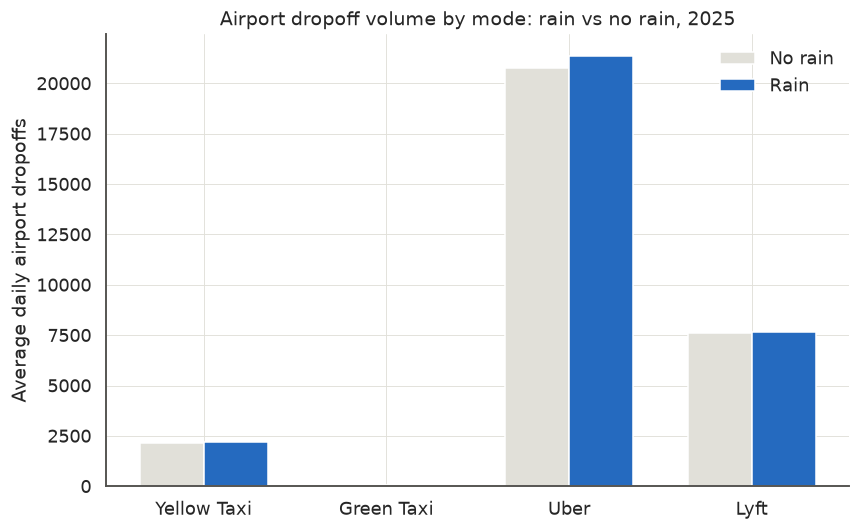

In [5]:
airport = pd.read_csv(f"{DATA_DIR}/processed/airport_dropoff_summary_2025.csv", parse_dates=["pickup_date"])
weather = pd.read_csv(f"{DATA_DIR}/weather/central_park_weather_2025.csv", parse_dates=["DATE"])
weather = weather.rename(columns={"DATE": "pickup_date"})
weather["is_rain"] = weather["PRCP"].fillna(0) > 0
weather["is_snow"] = weather["SNOW"].fillna(0) > 0

airport_wx = airport.merge(weather, on="pickup_date", how="left")

# weighted (by trip_count) summary per mode + airport, across the whole year
def weighted_avg(df, col, weight="trip_count"):
    return np.average(df[col], weights=df[weight])

METRICS = ["avg_distance_miles", "avg_duration_min", "avg_cost"]
METRIC_LABELS = {"avg_distance_miles": "Distance (mi)", "avg_duration_min": "Duration (min)", "avg_cost": "Cost ($)"}

rows = []
for (mode, airport_name), g in airport_wx.groupby(["mode", "airport"]):
    row = {"mode": mode, "airport": airport_name, "trip_count": g["trip_count"].sum()}
    for metric in METRICS:
        row[metric] = weighted_avg(g, metric)
    rows.append(row)
raw = pd.DataFrame(rows)
raw["trip_share_pct"] = raw.groupby("airport")["trip_count"].transform(lambda s: s / s.sum() * 100)

# Build a display table per airport: an "Average" row holding the reference
# value, then each mode's row shown as a % deviation from that reference --
# absolute mi/min/$ numbers are far less informative than "this service runs
# 20% pricier than the market average on this route".
#
# IMPORTANT (methods note for the report): the "Average" row is TRIP-COUNT-
# WEIGHTED across the 4 services, not a plain mean of the 4 numbers. An
# unweighted mean gives Green Taxi's airport figures (0.1-0.3% of trips,
# a few hundred rides/year -> noisy, easily swung by a handful of outlier
# long-haul trips) the SAME influence on the reference point as Uber's
# (~69% of trips, a robust average). That produced misleading deviations
# for every service, e.g. Green showing +139% distance at JFK pulling the
# unweighted "Average" up so far that Yellow/Uber/Lyft all looked further
# below-average than they really were. Weighting by trip_count makes the
# reference "what does the typical rider's trip actually look like" rather
# than "what's the average across four arbitrarily-defined categories" --
# a low-volume service can no longer distort the baseline everyone else is
# measured against.
display_tables = {}
for airport_name, g in raw.groupby("airport"):
    avg_row = {"mode": "Average", "trip_share_pct": np.nan}
    for metric in METRICS:
        avg_row[metric] = weighted_avg(g, metric)
    out_rows = [avg_row]
    for _, r in g.sort_values("mode").iterrows():
        out_row = {"mode": MODE_LABELS.get(r["mode"], r["mode"]), "trip_share_pct": r["trip_share_pct"]}
        for metric in METRICS:
            out_row[metric] = (r[metric] - avg_row[metric]) / avg_row[metric] * 100
        out_rows.append(out_row)
    tbl = pd.DataFrame(out_rows).set_index("mode")
    tbl = tbl.rename(columns={"trip_share_pct": "% of trips", **METRIC_LABELS})
    display_tables[airport_name] = tbl

for airport_name, tbl in display_tables.items():
    print(f"=== {airport_name} dropoffs, 2025 ===")
    print("(\"Average\" row = trip-count-weighted value across the 4 services; other rows = % deviation from it)")
    display(tbl.round(1))

# does rain/snow relate to airport-dropoff volume by mode?
daily_by_mode = airport_wx.groupby(["pickup_date", "mode"], as_index=False)["trip_count"].sum()
daily_by_mode = daily_by_mode.merge(weather[["pickup_date", "is_rain", "is_snow"]], on="pickup_date", how="left")

rain_effect = (
    daily_by_mode.groupby(["mode", "is_rain"])["trip_count"]
    .mean()
    .unstack("is_rain")
    .rename(columns={False: "avg_trips_no_rain", True: "avg_trips_rain"})
    .reindex(MODE_ORDER)
)
rain_effect["pct_change_on_rain"] = (
    (rain_effect["avg_trips_rain"] - rain_effect["avg_trips_no_rain"]) / rain_effect["avg_trips_no_rain"] * 100
)
print("\n=== Average daily airport-dropoff volume: rain vs no rain (both airports combined) ===")
display(rain_effect.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODE_ORDER))
width = 0.35
ax.bar(x - width / 2, rain_effect["avg_trips_no_rain"], width, label="No rain", color="#e1e0d9")
ax.bar(x + width / 2, rain_effect["avg_trips_rain"], width, label="Rain", color="#256abf")
ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER])
ax.set_ylabel("Average daily airport dropoffs")
ax.set_title("Airport dropoff volume by mode: rain vs no rain, 2025")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/airport_rain_effect_2025.png")
plt.show()

## 4. Special-event days vs normal days

A trip is flagged as an "event day" trip if its pickup date + pickup borough matches
a permitted NYC special event that day (`data/export.csv` — parades, street fairs,
marathons, etc; multi-day events are expanded across their date range, capped at 14
days to guard against bad rows). Compared within Manhattan, since that's where the
large majority of permitted events happen and where all four modes have real volume.

=== Manhattan: event day vs normal day, by mode ===
("Average" row = trip-count-weighted value across the 4 services for that day type; other rows = % deviation from it)

--- Normal day ---


,% of trips,Distance (mi),Duration (min),Cost ($)
mode,,,,
Average,NaN,3.8,18.5,33.6
Green Taxi,0.3,-35.6,0.4,-34.3
Lyft,19.4,14.1,8.5,-0.8
Uber,49.9,17.1,8.6,17.1
Yellow Taxi,30.4,-36.8,-19.6,-27.2



--- Event day ---


,% of trips,Distance (mi),Duration (min),Cost ($)
mode,,,,
Average,NaN,3.9,18.3,32.8
Green Taxi,0.2,-37.0,1.0,-34.5
Lyft,20.4,10.6,6.9,0.3
Uber,49.4,16.9,8.7,15.8
Yellow Taxi,29.9,-34.9,-19.1,-26.2


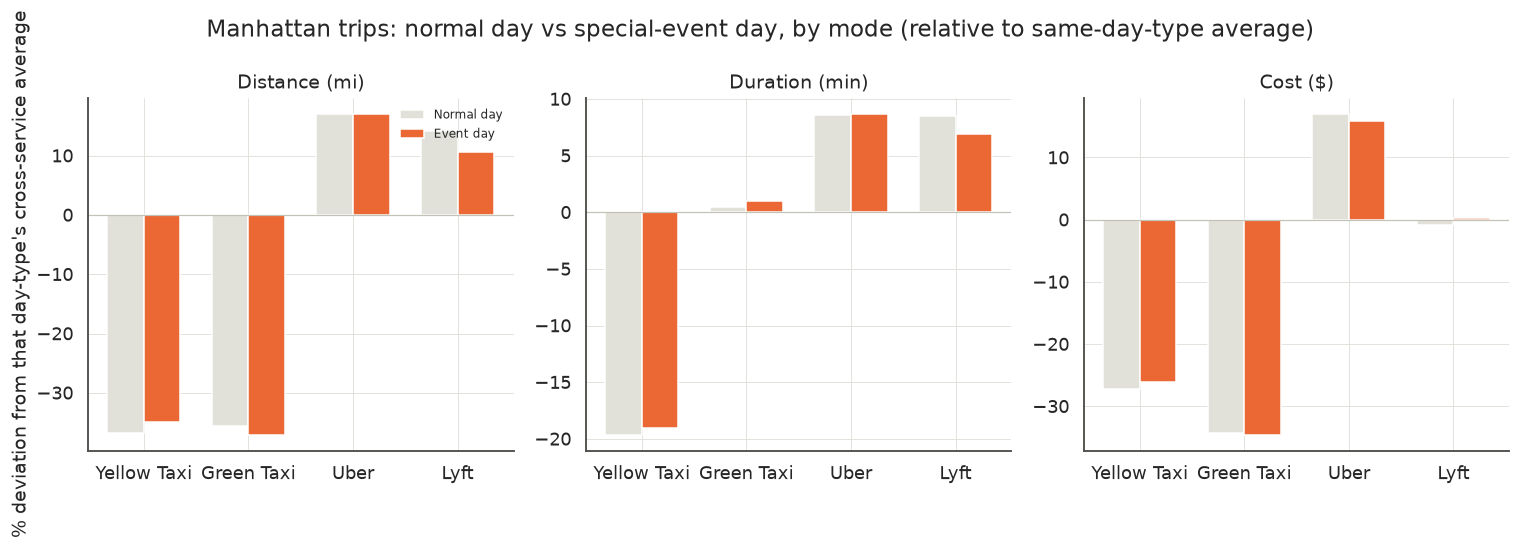

In [6]:
event_summary = pd.read_csv(f"{DATA_DIR}/processed/event_day_trip_summary_2025.csv")
manhattan = event_summary[(event_summary["Borough"] == "Manhattan") & (event_summary["mode"].isin(MODE_ORDER))].copy()
manhattan["day_type"] = manhattan["is_event_day"].map(
    {True: "Event day", False: "Normal day", "True": "Event day", "False": "Normal day"}
)

METRICS = ["avg_distance_miles", "avg_duration_min", "avg_cost"]
METRIC_LABELS = {"avg_distance_miles": "Distance (mi)", "avg_duration_min": "Duration (min)", "avg_cost": "Cost ($)"}

# % of that day-type's trips taken by each mode
manhattan["trip_share_pct"] = manhattan.groupby("day_type")["trip_count"].transform(lambda s: s / s.sum() * 100)


def weighted_avg(df, col, weight="trip_count"):
    return np.average(df[col], weights=df[weight])


# "Average" reference = TRIP-COUNT-WEIGHTED across-mode average WITHIN each
# day-type (event days and normal days have different overall levels, so the
# reference has to be computed separately for each, not pooled). Weighted
# rather than a plain mean for the same reason as the airport table above:
# Green Taxi is <1% of Manhattan trips, and an unweighted mean would let its
# noisy small-sample average distort the baseline every other service is
# compared against. See the note on the airport-summary cell for the full
# explanation and a concrete before/after example.
for metric in METRICS:
    weighted_ref = manhattan.groupby("day_type").apply(
        lambda g: weighted_avg(g, metric), include_groups=False
    )
    manhattan[f"{metric}_ref"] = manhattan["day_type"].map(weighted_ref)
    manhattan[f"{metric}_dev"] = (manhattan[metric] - manhattan[f"{metric}_ref"]) / manhattan[f"{metric}_ref"] * 100

print("=== Manhattan: event day vs normal day, by mode ===")
print("(\"Average\" row = trip-count-weighted value across the 4 services for that day type; other rows = % deviation from it)")
for day_type in ["Normal day", "Event day"]:
    sub = manhattan[manhattan["day_type"] == day_type]
    avg_row = {"mode": "Average", "% of trips": np.nan}
    for metric in METRICS:
        avg_row[METRIC_LABELS[metric]] = sub[f"{metric}_ref"].iloc[0]
    out_rows = [avg_row]
    for _, r in sub.sort_values("mode").iterrows():
        out_row = {"mode": MODE_LABELS.get(r["mode"], r["mode"]), "% of trips": r["trip_share_pct"]}
        for metric in METRICS:
            out_row[METRIC_LABELS[metric]] = r[f"{metric}_dev"]
        out_rows.append(out_row)
    print(f"\n--- {day_type} ---")
    display(pd.DataFrame(out_rows).set_index("mode").round(1))

# visual: % deviation from that day-type's average, normal vs event, per metric
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
x = np.arange(len(MODE_ORDER))
width = 0.35
for ax, metric in zip(axes, METRICS):
    normal_vals = [manhattan[(manhattan["mode"] == m) & (manhattan["day_type"] == "Normal day")][f"{metric}_dev"].values[0] for m in MODE_ORDER]
    event_vals = [manhattan[(manhattan["mode"] == m) & (manhattan["day_type"] == "Event day")][f"{metric}_dev"].values[0] for m in MODE_ORDER]
    ax.bar(x - width / 2, normal_vals, width, label="Normal day", color="#e1e0d9")
    ax.bar(x + width / 2, event_vals, width, label="Event day", color="#eb6834")
    ax.axhline(0, color="#c3c2b7", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER])
    ax.set_title(METRIC_LABELS[metric])
axes[0].set_ylabel("% deviation from that day-type's cross-service average")
axes[0].legend(frameon=False, loc="upper right", fontsize=8)
fig.suptitle("Manhattan trips: normal day vs special-event day, by mode (relative to same-day-type average)")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/event_day_comparison_2025.png")
plt.show()

## 5. Weather deep dive

The rain/no-rain airport comparison above is a blunt instrument (binary flag, whole
day). Here we use continuous weather variables and, for the intraday question, real
hourly timing instead of a daily flag:

- **Daily**: mean temperature (°C) and total precipitation (mm) vs. daily trip volume,
  correlation per mode, full year 2025 (Central Park daily station).
- **Hourly**: was it *actually raining/snowing in that specific hour*, from LaGuardia's
  hourly METAR observations (`HourlyPresentWeatherType` + measured precip), compared
  against trip volume in the *same* hour — and compared **within the same hour-of-day**
  so we're not just picking up the fact that rain happens to cluster at certain times.

**Coverage note**: NOAA's hourly product for this station only has 2025 data through
August so far (Sep-Dec not yet processed on their end) — the hourly analysis below
covers Jan-Aug 2025 (~5,660 of 8,760 hours), not the full year. The daily analysis
above is unaffected (full year, different data source).

=== Pearson correlation: daily mean temp (C) vs trip volume (% deviation from that mode's day-of-week average) ===
  Yellow Taxi: r=0.028, p=5.99e-01, n=365
  Green Taxi: r=-0.058, p=2.66e-01, n=365
  Uber: r=-0.437, p=1.77e-18, n=365


  Lyft: r=-0.021, p=6.95e-01, n=365

=== Pearson correlation: daily precipitation (mm) vs trip volume (% deviation from that mode's day-of-week average) ===
  Yellow Taxi: r=0.149, p=4.47e-03, n=365
  Green Taxi: r=0.119, p=2.31e-02, n=365
  Uber: r=0.200, p=1.18e-04, n=365
  Lyft: r=0.145, p=5.53e-03, n=365


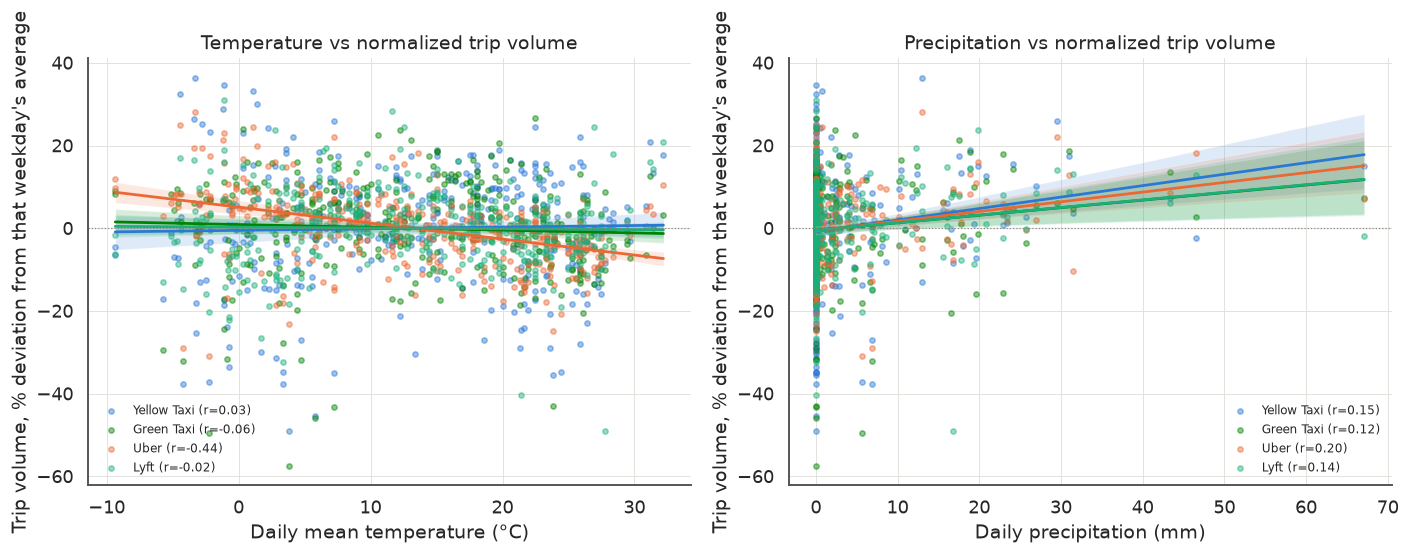

In [7]:
from scipy.stats import pearsonr

daily_wx = pd.read_csv(f"{DATA_DIR}/processed/daily_weather_2025.csv", parse_dates=["date"])
daily_trips_wx = daily_wide.reset_index().rename(columns={"pickup_date": "date"}).merge(daily_wx, on="date", how="left")
daily_trips_wx["dow"] = daily_trips_wx["date"].dt.day_name()

# Normalize: raw trip counts put Uber (much higher baseline volume) on a totally
# different scale than yellow/Lyft, and volume is also driven hugely by day-of-week
# (see section 2) which has nothing to do with weather. Express each day as a
# % deviation from THAT MODE's own typical volume for THAT day-of-week, so all
# three modes sit on the same relative scale and the day-of-week confound is
# removed before looking for a weather effect.
for m in MODE_ORDER:
    dow_mean = daily_trips_wx.groupby("dow")[m].transform("mean")
    daily_trips_wx[f"{m}_pct_dev"] = (daily_trips_wx[m] - dow_mean) / dow_mean * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

print("=== Pearson correlation: daily mean temp (C) vs trip volume (% deviation from that mode's day-of-week average) ===")
for m in MODE_ORDER:
    col = f"{m}_pct_dev"
    sub = daily_trips_wx.dropna(subset=["temp_c_mean", col])
    r, p = pearsonr(sub["temp_c_mean"], sub[col])
    sns.regplot(
        data=sub, x="temp_c_mean", y=col, ax=axes[0], color=MODE_COLORS[m],
        scatter_kws={"s": 12, "alpha": 0.45}, line_kws={"linewidth": 1.8},
        label=f"{MODE_LABELS[m]} (r={r:.2f})", ci=95,
    )
    print(f"  {MODE_LABELS[m]}: r={r:.3f}, p={p:.2e}, n={len(sub)}")
axes[0].axhline(0, color="#898781", linewidth=0.8, linestyle=":")
axes[0].set_xlabel("Daily mean temperature (°C)")
axes[0].set_ylabel("Trip volume, % deviation from that weekday's average")
axes[0].set_title("Temperature vs normalized trip volume")
axes[0].legend(frameon=False, fontsize=8)

print("\n=== Pearson correlation: daily precipitation (mm) vs trip volume (% deviation from that mode's day-of-week average) ===")
for m in MODE_ORDER:
    col = f"{m}_pct_dev"
    sub = daily_trips_wx.dropna(subset=["precip_mm_total", col])
    r, p = pearsonr(sub["precip_mm_total"], sub[col])
    sns.regplot(
        data=sub, x="precip_mm_total", y=col, ax=axes[1], color=MODE_COLORS[m],
        scatter_kws={"s": 12, "alpha": 0.45}, line_kws={"linewidth": 1.8},
        label=f"{MODE_LABELS[m]} (r={r:.2f})", ci=95,
    )
    print(f"  {MODE_LABELS[m]}: r={r:.3f}, p={p:.2e}, n={len(sub)}")
axes[1].axhline(0, color="#898781", linewidth=0.8, linestyle=":")
axes[1].set_xlabel("Daily precipitation (mm)")
axes[1].set_ylabel("Trip volume, % deviation from that weekday's average")
axes[1].set_title("Precipitation vs normalized trip volume")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/daily_weather_correlation_2025.png")
plt.show()

### Hourly: is it raining *right now*, controlled for hour-of-day

Naively comparing "trips during rain hours" vs "trips during dry hours" is confounded —
rain doesn't fall uniformly across hours/seasons. Instead, for each hour-of-day (0-23)
we compare the average trip count on hours *within that same hour-of-day* that were
raining vs not, then look at the pattern across the day.

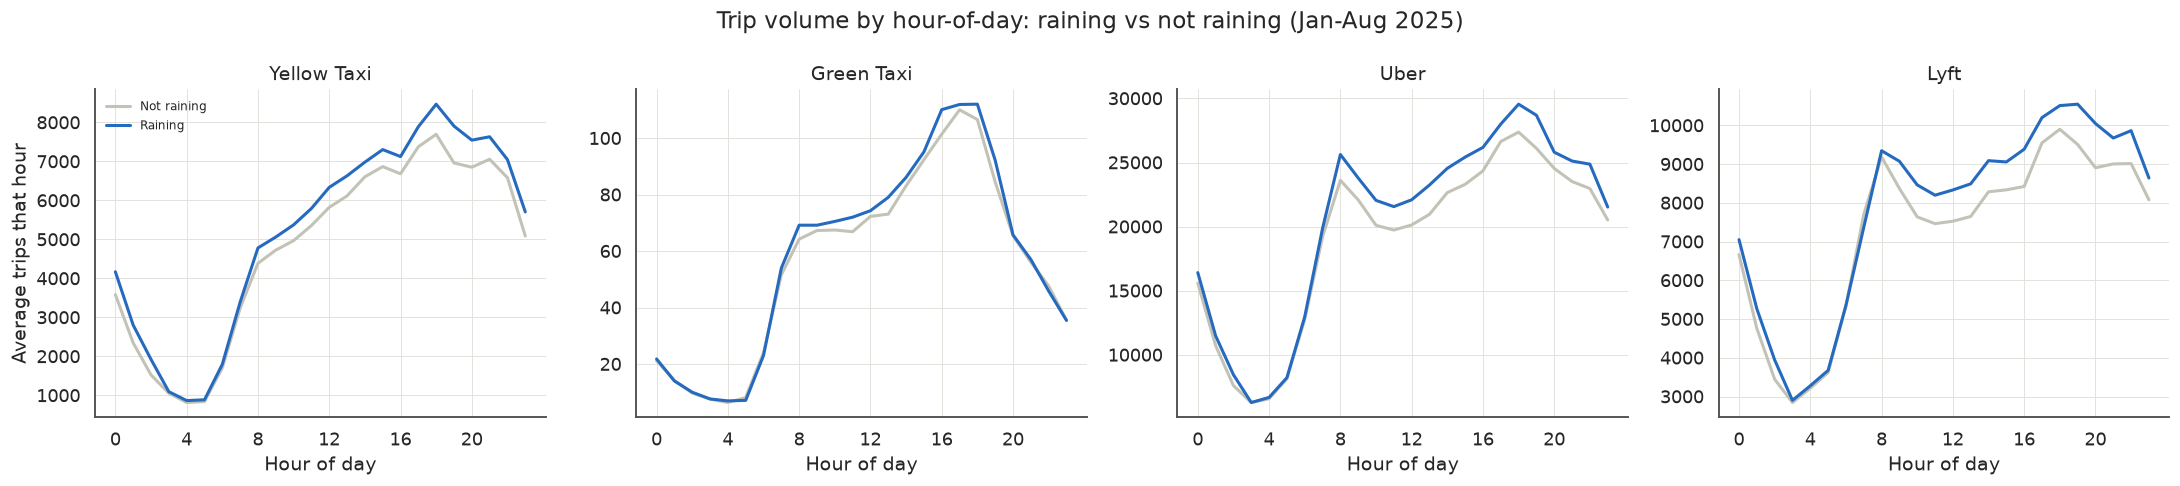

=== % change in average trips when raining, by hour-of-day (positive = more trips in rain) ===


mode,green,lyft,uber,yellow
hour,,,,
0,3.3,5.8,5.2,16.3
1,-2.0,10.7,7.1,19.5
2,3.4,14.5,11.1,26.1
3,0.3,2.0,0.1,3.6
4,9.3,2.0,1.6,6.2
5,-12.6,1.6,1.0,5.4
6,-4.3,0.4,1.6,5.4
7,4.6,-4.3,3.4,4.8
8,7.7,1.7,8.5,9.0



=== Overall (hour-of-day-adjusted-by-eye) rain effect ===


is_raining,False,True,pct_diff
mode,,,
green,55.97,57.33,2.42
lyft,7269.27,7805.13,7.37
uber,18985.43,20269.61,6.76
yellow,4762.42,5167.62,8.51


In [8]:
hourly = pd.read_csv(f"{DATA_DIR}/processed/hourly_trips_weather_2025.csv", parse_dates=["date"])
BOOL_MAP = {True: True, False: False, "True": True, "False": False}
hourly["is_raining"] = hourly["is_raining"].map(BOOL_MAP)
hourly["is_snowing"] = hourly["is_snowing"].map(BOOL_MAP)
hourly = hourly.dropna(subset=["is_raining"])  # keep only hours with a real weather observation
hourly = hourly[hourly["mode"].isin(MODE_ORDER)]

by_hour_rain = (
    hourly.groupby(["mode", "hour", "is_raining"])["trip_count"].mean().unstack("is_raining")
    .rename(columns={False: "no_rain", True: "rain"})
)
by_hour_rain["pct_diff"] = (by_hour_rain["rain"] - by_hour_rain["no_rain"]) / by_hour_rain["no_rain"] * 100

fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(5 * len(MODE_ORDER), 4.5), sharex=True)
for ax, m in zip(axes, MODE_ORDER):
    sub = by_hour_rain.loc[m]
    ax.plot(sub.index, sub["no_rain"], color="#c3c2b7", linewidth=2, label="Not raining")
    ax.plot(sub.index, sub["rain"], color="#256abf", linewidth=2, label="Raining")
    ax.set_title(MODE_LABELS[m])
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 24, 4))
axes[0].set_ylabel("Average trips that hour")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Trip volume by hour-of-day: raining vs not raining (Jan-Aug 2025)")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/hourly_rain_by_hour_of_day_2025.png")
plt.show()

print("=== % change in average trips when raining, by hour-of-day (positive = more trips in rain) ===")
display(by_hour_rain["pct_diff"].unstack("mode").round(1))

overall_effect = hourly.groupby(["mode", "is_raining"])["trip_count"].mean().unstack("is_raining")
overall_effect["pct_diff"] = (overall_effect[True] - overall_effect[False]) / overall_effect[False] * 100
print("\n=== Overall (hour-of-day-adjusted-by-eye) rain effect ===")
display(overall_effect.round(2))

### Rain intensity (mm/hour) and snow

Does it matter *how hard* it's raining, not just whether it's raining — and is snow
(much rarer, but arguably more disruptive to street-hail than app dispatch) different?

=== Rain intensity (mm/hr) vs hour-of-day-normalized trip volume (% dev), raining hours only ===
  Yellow Taxi: r=0.086, p=0.003, n=1168
  Green Taxi: r=0.063, p=0.031, n=1166
  Uber: r=0.101, p=0.001, n=1168


  Lyft: r=0.050, p=0.088, n=1168


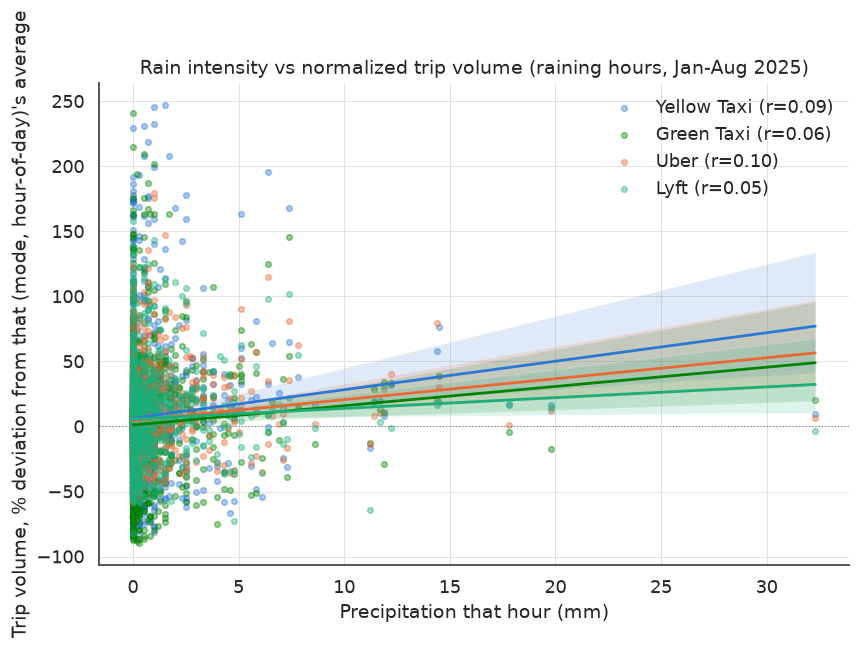


=== Snow hours vs non-snow hours, average trip count ===


mean          count      
is_snowing    False    True  False True 
mode                                    
green          56.3     47.3  8501   112
lyft         7339.5   7510.6  8532   112
uber        19130.8  21302.0  8532   112
yellow       4812.8   5154.0  8532   112


Total snowing hours in Jan-Aug 2025 sample: 448 -- small sample, treat as indicative only


In [9]:
# rain intensity: among raining hours only, does heavier rain (mm) relate to trip volume?
# normalize to % deviation from that (mode, hour-of-day)'s own mean -- same reasoning
# as the daily section: Uber's raw volume dwarfs yellow/Lyft's, so raw counts (or raw
# residuals) aren't comparable across modes on one axis; % deviation is.
hour_mode_mean = hourly.groupby(["mode", "hour"])["trip_count"].transform("mean")
hourly["trip_count_pct_dev"] = (hourly["trip_count"] - hour_mode_mean) / hour_mode_mean * 100
raining_hours = hourly[hourly["is_raining"] & hourly["precip_mm"].notna()].copy()

fig, ax = plt.subplots(figsize=(8, 5.5))
print("=== Rain intensity (mm/hr) vs hour-of-day-normalized trip volume (% dev), raining hours only ===")
for m in MODE_ORDER:
    sub = raining_hours[raining_hours["mode"] == m]
    if len(sub) > 2:
        r, p = pearsonr(sub["precip_mm"], sub["trip_count_pct_dev"])
        print(f"  {MODE_LABELS[m]}: r={r:.3f}, p={p:.3f}, n={len(sub)}")
        sns.regplot(
            data=sub, x="precip_mm", y="trip_count_pct_dev", ax=ax, color=MODE_COLORS[m],
            scatter_kws={"s": 14, "alpha": 0.4}, line_kws={"linewidth": 1.8},
            label=f"{MODE_LABELS[m]} (r={r:.2f})", ci=95,
        )
ax.axhline(0, color="#898781", linewidth=0.8, linestyle=":")
ax.set_xlabel("Precipitation that hour (mm)")
ax.set_ylabel("Trip volume, % deviation from that (mode, hour-of-day)'s average")
ax.set_title("Rain intensity vs normalized trip volume (raining hours, Jan-Aug 2025)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/rain_intensity_2025.png")
plt.show()

# snow effect (rare -- small sample, report with caution)
print("\n=== Snow hours vs non-snow hours, average trip count ===")
snow_effect = hourly.groupby(["mode", "is_snowing"])["trip_count"].agg(["mean", "count"]).unstack("is_snowing")
display(snow_effect.round(1))
print(f"\nTotal snowing hours in Jan-Aug 2025 sample: {hourly['is_snowing'].sum()} -- small sample, treat as indicative only")